# Week 6 - Bivariate Analysis, part 2

# 1. Lesson: no lesson this week

# 2. Weekly graph question

Suppose you wanted to show the nitrate and phosphate level in a water sample.  What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs?  How would you adjust the graphs shown to improve the presentation?

In [2]:
import numpy as np
import seaborn as sns
import pandas as pd

Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

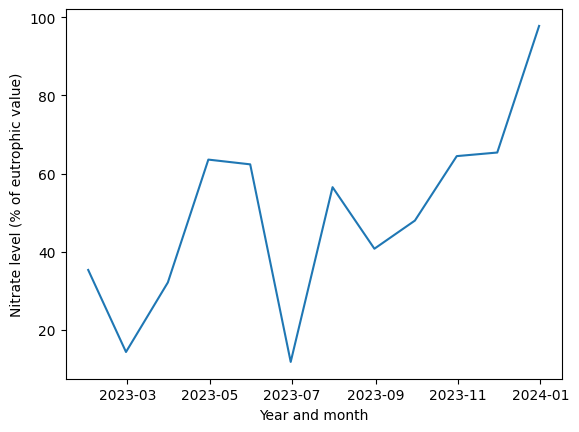

In [3]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

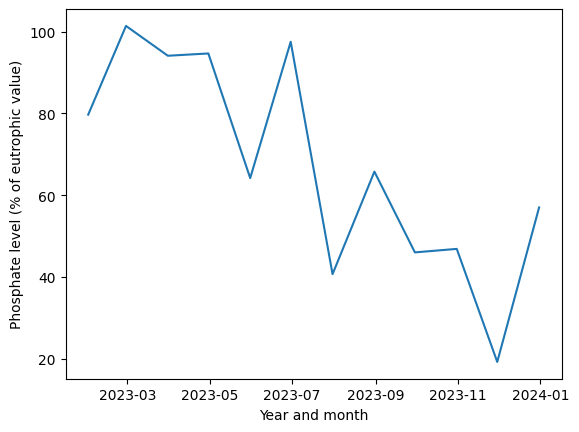

In [5]:
np.random.seed(1)
time_series_2 =  100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

<Axes: >

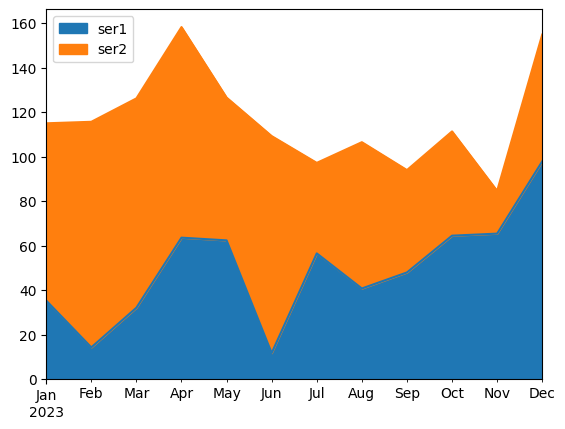

In [6]:
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Find correlations between pairs of variables.

- Draw scatterplots, especially when the correlation is large.

- Draw pairplots.

- Draw line graphs and/or area graphs when there is date or time data together with numerical data.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!

- Do you see any outliers?  (Data points that are far from the rest of the data).

- Are any data items highly correlated with each other, suggesting that they are redundant?

- For the line plots, do you see a trend or pattern over time?  Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?

- Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)

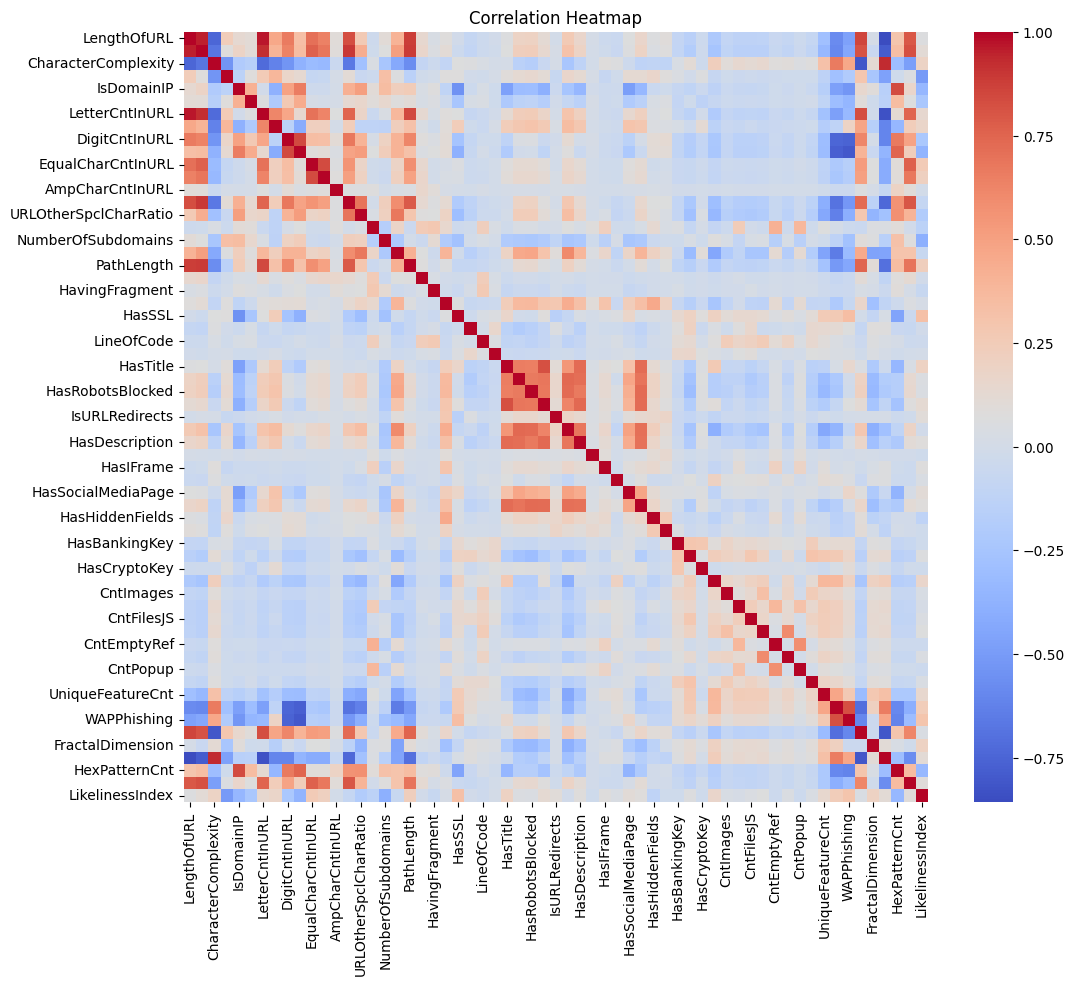

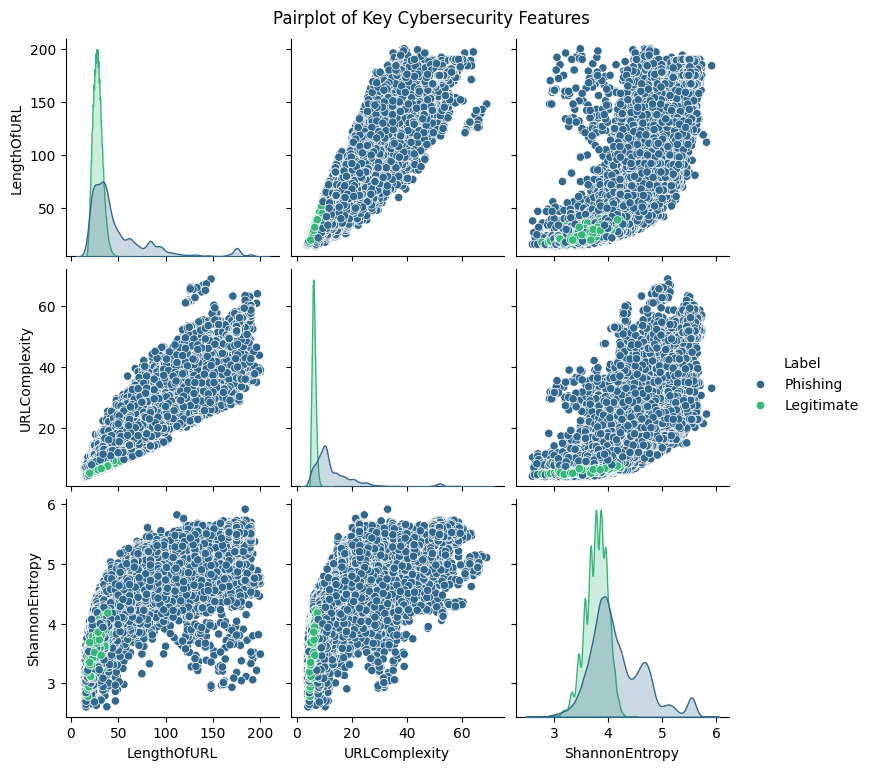

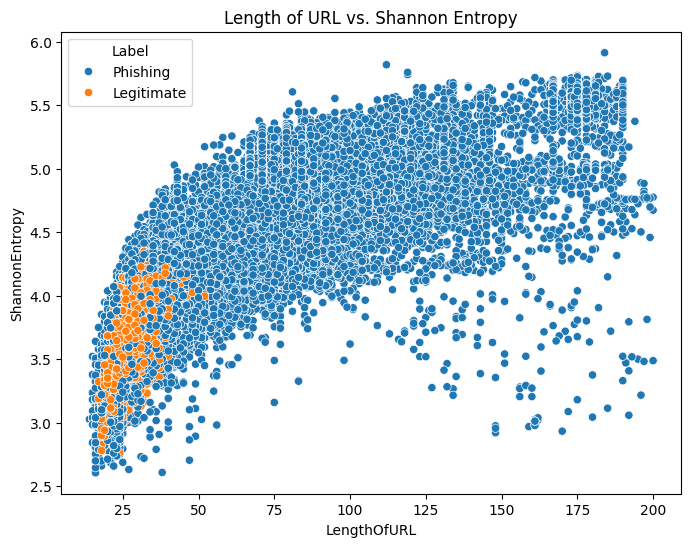

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load your dataset
df = pd.read_csv('StealthPhisher2025.csv')

# 2. Select numerical columns for correlation and plots
# We drop non-numerical strings like 'URL', 'Domain', and 'TLD'
df_num = df.select_dtypes(include=['float64', 'int64'])

# 3. Correlation Heatmap
plt.figure(figsize=(12, 10))
correlation_matrix = df_num.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# 4. Pairplot to see relationships between key features
# We limit to a few features to avoid an unreadable plot
key_features = ['LengthOfURL', 'URLComplexity', 'ShannonEntropy', 'Label']
sns.pairplot(df[key_features], hue='Label', palette='viridis')
plt.suptitle('Pairplot of Key Cybersecurity Features', y=1.02)
plt.show()

# 5. Scatterplot for highly correlated variables
# Example: LengthOfURL vs ShannonEntropy
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='LengthOfURL', y='ShannonEntropy', hue='Label')
plt.title('Length of URL vs. Shannon Entropy')
plt.show()

•	Data Usability: The data is highly structured and likely usable for machine learning, as it provides a comprehensive set of numerical features for each URL. However, rows containing extremely long or mangled URLs (like some of the IPFS/encoded links) may act as noise. 

•	Outliers: You will likely find outliers in features like LengthOfURL or LongestLineLength. Some phishing URLs are extremely long (over 100 characters) compared to the average legitimate URL, which typically hovers around 20–40 characters. These are not necessarily "errors"—they are characteristic features of phishing attempts.


•	Redundancy: Check if features like LengthOfURL and DomainLengthOfURL are perfectly or highly correlated. If they are, one could be dropped to reduce dimensionality.

•	Confounding Variables: A major confounding variable could be the age of the domain. Legitimate domains (like university or government sites) tend to be older. The dataset does not contain "DomainAge," which might actually be a stronger predictor than the URL features themselves. Another is the hosting platform—many phishing sites in this dataset are hosted on free services (e.g., web.app, firebaseapp.com, gitbook.io). This platform choice is a strong signal that might be masking the underlying technical complexity of the links.


# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 86-98 of the Storytelling With Data book as best you can.  (The second half of chapter three).  You do not have to get the exact data values right, just the overall look and feel.